In [1]:
!pwd

/home/alan_khang/dev/mirror3d


In [1]:
import sys, os

root = os.getcwd()

sys.path.append(f"{root}/mirror3d/mirror3dnet")

In [2]:
from mirror3d.utils import RefineDepth, read_json, unit_vector
from mirror3d_lib.engine.defaults import Mirror3dTrainer
from mirror3d_lib.config.config import get_cfg
from mirror3d_lib.data.datasets.register_mirror3d_coco import register_mirror3d_coco_instances

from detectron2.checkpoint import DetectionCheckpointer
from detectron2.evaluation import inference_context
from detectron2.utils.visualizer import Visualizer
from detectron2.utils.visualizer import ColorMode
from detectron2.data import MetadataCatalog
from detectron2.engine.defaults import DefaultPredictor
from detectron2.modeling import build_model

import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
import shutil

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [3]:
cfg_file = './mirror3d/mirror3dnet/config/mirror3dnet_config.yml'

cfg = get_cfg() 
cfg.merge_from_file(cfg_file)

# MODEL
cfg.ANCHOR_NORMAL_NYP = './data/Mirror-Glass_Segmentation.v11i.coco-segmentation/kmeans_normal_10.npy'
cfg.MODEL.WEIGHTS = '/home/alan_khang/dev/mirror3d/output/mirror_glass_segm_v11/m3n_full_rawD_resume_2026-03-30-21-24-40/model_0005999.pth'
cfg.ANCHOR_NORMAL_CLASS_NUM = np.load(cfg.ANCHOR_NORMAL_NYP).shape[0]

# DATASET
cfg.VAL_COCO_JSON = './data/Mirror-Glass_Segmentation.v11i.coco-segmentation/valid_annot.json'
cfg.VAL_IMG_ROOT = './data/Mirror-Glass_Segmentation.v11i.coco-segmentation'

val_name = cfg.VAL_IMG_ROOT.split("/")[-1].split(".")[0]
register_mirror3d_coco_instances(val_name, {}, cfg.VAL_COCO_JSON, cfg.VAL_IMG_ROOT) 

cfg.VAL_NAME = val_name
cfg.DATASETS.TEST = [val_name]
cfg.REFINED_DEPTH = True
cfg.FOCAL_LENGTH = 524 
cfg.DEPTH_SHIFT = 1000 
cfg.EVAL_HEIGHT = 360
cfg.EVAL_WIDTH = 640 
cfg.INPUT.MIN_SIZE_TEST = 360
cfg.INPUT.MAX_SIZE_TEST = 640
cfg.REF_MODE = "rawD_border"

predictor = DefaultPredictor(cfg)
data_loader = Mirror3dTrainer.build_test_loader(cfg, cfg.DATASETS.TEST[0])
depth_refiner = RefineDepth(cfg.FOCAL_LENGTH, cfg.REF_BORDER_WIDTH, cfg.EVAL_WIDTH, cfg.EVAL_HEIGHT)

In [4]:
batch_0 = list(iter(data_loader))[0]

/home/alan_khang/dev/detectron2/detectron2/structures/boxes.py:148: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:261.)
  tensor = torch.as_tensor(tensor, dtype=torch.float32, device=torch.device("cpu"))
/home/alan_khang/dev/detectron2/detectron2/structures/boxes.py:148: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:261.)
  tensor = torch.as_tensor(tensor, dtype=torch.float32, device=torch.device("cpu"))
/home/alan_khang/dev/detectron2/detectron2/structures/boxes.py:148: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the l

In [121]:
with torch.no_grad():
    output_batch_0 = predictor.model(batch_0)

In [9]:
score_thresh = 0.7
cnt = 0

output_list = []
with inference_context(model), torch.no_grad():
    for idx, inputs in enumerate(data_loader):
        if cnt == 1:
            break
        if idx < 10:
            continue
        outputs = model(inputs)

        for output in outputs[0]:
            output["instances"] = output["instances"][output["instances"].scores > score_thresh]

        # append some of input information to output_list[]; output_list contrains 
        #  (1) input infomation 
        #  (2) predict depth / predict instance (contains anchor scores, anchor classes, pred boxes.. etc) 
        input_temp = []
        for item in inputs:
            temp = item.copy()
            temp.pop("image")
            if "depth_image" in temp:
                temp.pop("depth_image")
            input_temp.append(temp)
        output_list.append([outputs, input_temp])
        cnt += 1

/home/alan_khang/dev/detectron2/detectron2/structures/boxes.py:148: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:261.)
  tensor = torch.as_tensor(tensor, dtype=torch.float32, device=torch.device("cpu"))


In [10]:
anchor_normal = np.load(cfg.ANCHOR_NORMAL_NYP)
imgPath_info = dict()

input_json = read_json(cfg.VAL_COCO_JSON)
for item in input_json["images"]:
    img_path = os.path.join(cfg.VAL_IMG_ROOT, item["mirror_color_image_path"])
    
    imgPath_info[img_path] = item

for i, item in enumerate(output_list):
    one_output, one_input = item
    instances = one_output[0][0]["instances"]
    color_img_path = one_input[0]["mirror_color_image_path"]
    hole_raw_depth_path = os.path.join(cfg.VAL_IMG_ROOT, imgPath_info[color_img_path]["raw_sensorD_path"])

    pred_mask = np.zeros(instances.image_size)
    pred_mask = pred_mask.astype(bool)

    hole_depth_to_ref = cv2.imread(hole_raw_depth_path, cv2.IMREAD_ANYDEPTH)

    if instances.to("cpu").has("pred_masks"):
        for index, one_pred_mask in enumerate(instances.to("cpu").pred_masks):
            
            to_refine_area = one_pred_mask.numpy().astype(bool)
            to_refine_area = np.logical_and(pred_mask==False, to_refine_area)
            if to_refine_area.sum() == 0:
                continue
            pred_mask = np.logical_or(pred_mask , one_pred_mask)
            if instances.to("cpu").pred_anchor_classes[index] >= anchor_normal.shape[0]:
                continue
            pred_normal = anchor_normal[instances.to("cpu").pred_anchor_classes[index]] +  instances.to("cpu").pred_residuals[index].numpy()
            pred_normal = unit_vector(pred_normal)

            if "border" in cfg.REF_MODE :
                hole_depth_to_ref = depth_refiner.refine_depth_by_mirror_border(
                    one_pred_mask.numpy().astype(bool).squeeze(), 
                    pred_normal, 
                    hole_depth_to_ref)
            else:
                raise NotImplementedError("Only border-based refine mode is implemented for now.")
    
    hole_depth_to_ref[hole_depth_to_ref < 0] = 0

In [11]:
for one_output, one_input in output_list:
    instances = one_output[0][0]["instances"]
    if instances.pred_boxes.tensor.shape[0] <= 0:
        print("######## no detection :", img_path)
    img = cv2.imread(img_path)
    v = Visualizer(img[:, :, ::-1], 
        metadata=MetadataCatalog.get("test_10_precise_normal_mirror"), 
        scale=0.5, 
        instance_mode=ColorMode.IMAGE_BW  
    )
    v = v.draw_instance_predictions(instances.to("cpu")) 
    output_img = v.get_image()[:, :, ::-1]

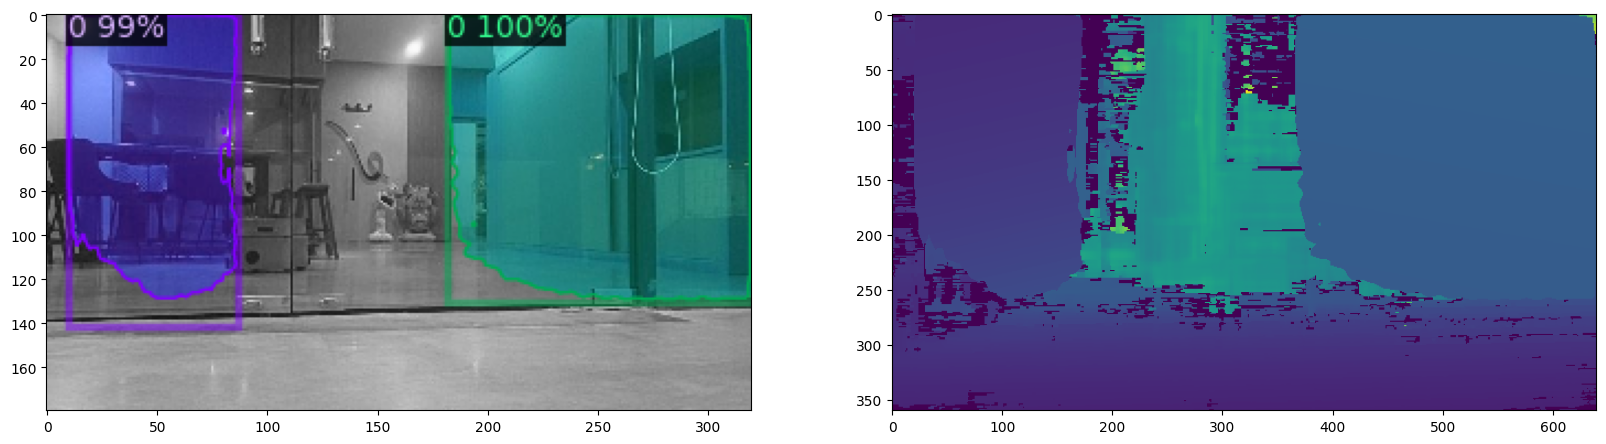

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
axes[0].imshow(output_img)
axes[1].imshow(hole_depth_to_ref, cmap="viridis")
plt.show()

In [4]:
ori_img_1 = cv2.imread('/home/alan_khang/dataset_zoo/guilder_captured_data/2026_03_23/2026_03_23:20:56:12/oak_right/color/oak_right_frame_0000176.jpg')
ori_depth_1 = cv2.imread('/home/alan_khang/dataset_zoo/guilder_captured_data/2026_03_23/2026_03_23:20:56:12/oak_right/depth/oak_right_frame_0000176.png', cv2.IMREAD_ANYDEPTH)

ori_img_2 = cv2.imread('/home/alan_khang/dataset_zoo/guilder_captured_data/2026_03_23/2026_03_23:20:56:12/oak_right/color/oak_right_frame_0000250.jpg')
ori_depth_2 = cv2.imread('/home/alan_khang/dataset_zoo/guilder_captured_data/2026_03_23/2026_03_23:20:56:12/oak_right/depth/oak_right_frame_0000250.png', cv2.IMREAD_ANYDEPTH)

ori_img_3 = cv2.imread('/home/alan_khang/dataset_zoo/guilder_captured_data/2026_03_23/2026_03_23:20:56:12/oak_right/color/oak_right_frame_0000300.jpg')
ori_depth_3 = cv2.imread('/home/alan_khang/dataset_zoo/guilder_captured_data/2026_03_23/2026_03_23:20:56:12/oak_right/depth/oak_right_frame_0000300.png', cv2.IMREAD_ANYDEPTH)

ori_h, ori_w, _ = ori_img_1.shape
img_1 = cv2.resize(ori_img_1, (cfg.EVAL_WIDTH, cfg.EVAL_HEIGHT))
img_1 = torch.from_numpy(img_1).permute(2, 0, 1)

img_2 = cv2.resize(ori_img_2, (cfg.EVAL_WIDTH, cfg.EVAL_HEIGHT))
img_2 = torch.from_numpy(img_2).permute(2, 0, 1)

img_3 = cv2.resize(ori_img_3, (cfg.EVAL_WIDTH, cfg.EVAL_HEIGHT))
img_3 = torch.from_numpy(img_3).permute(2, 0, 1)

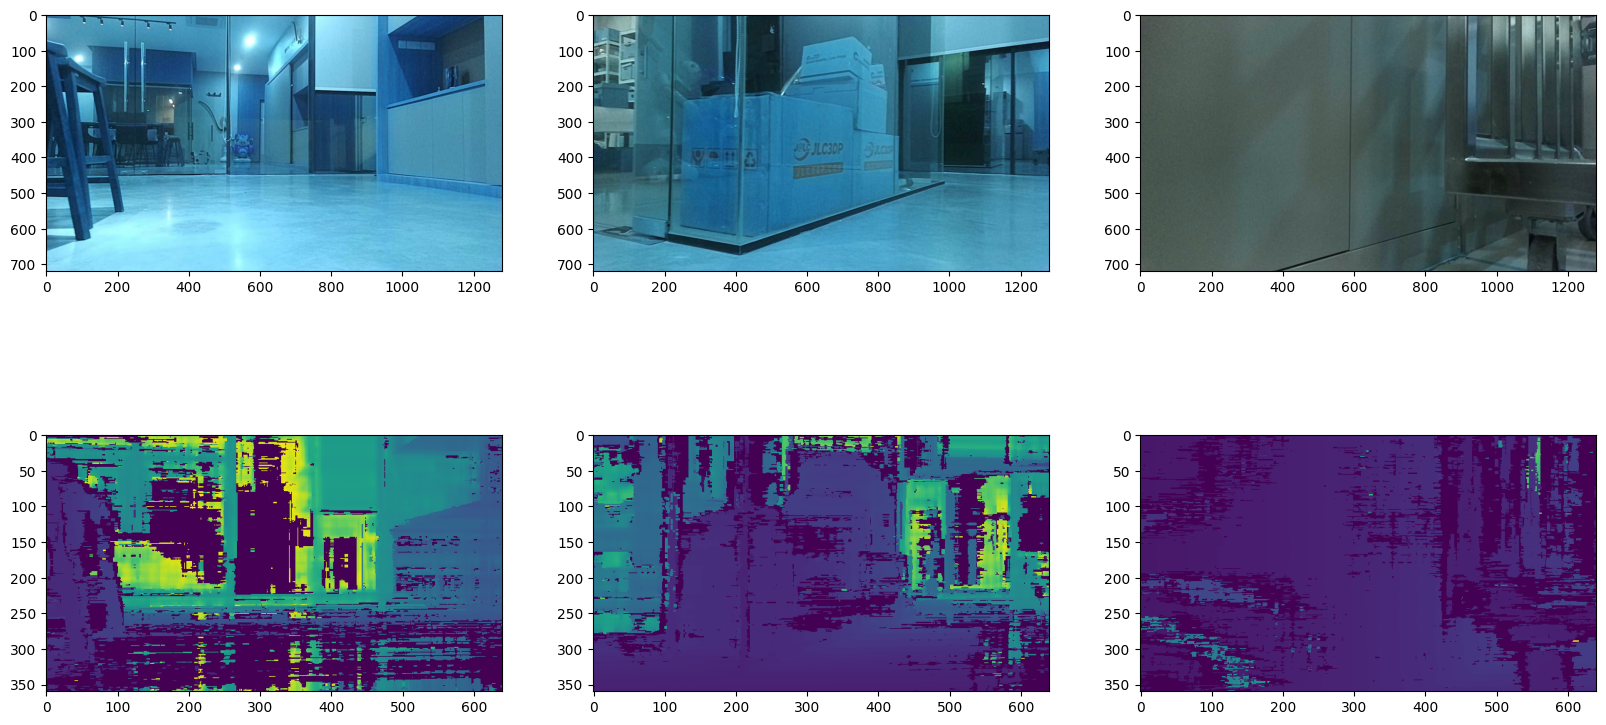

In [5]:
_, axs = plt.subplots(2, 3, figsize=(20, 10))
axs[0, 0].imshow(ori_img_1)
axs[0, 1].imshow(ori_img_2)
axs[0, 2].imshow(ori_img_3)

axs[1, 0].imshow(ori_depth_1, cmap="viridis")
axs[1, 1].imshow(ori_depth_2, cmap="viridis")
axs[1, 2].imshow(ori_depth_3, cmap="viridis")

plt.show()

In [24]:
dump_batch = [
    {'image': img_1, 'height': ori_h, 'width': ori_w, 'ori_depth_img': ori_depth_1, 'ori_img': ori_img_1},
    {'image': img_2, 'height': ori_h, 'width': ori_w, 'ori_depth_img': ori_depth_2, 'ori_img': ori_img_2},
    {'image': img_3, 'height': ori_h, 'width': ori_w, 'ori_depth_img': ori_depth_3, 'ori_img': ori_img_3}]

In [25]:
with torch.no_grad():
    rs = predictor.model(dump_batch)

In [26]:
score_thresh = 0.7
cnt = 0

anchor_normal = np.load(cfg.ANCHOR_NORMAL_NYP)

for r in rs[0]:
    r["instances"] = r["instances"][r["instances"].scores > score_thresh]

for i, one_output in enumerate(rs[0]):
    instances = one_output["instances"].to('cpu')
    pred_bboxes = instances.pred_boxes.tensor.detach().numpy()
    pred_masks = instances.pred_masks.detach().numpy()
    pred_anchor_residuals = instances.pred_residuals.detach().numpy()
    pred_anchors_cls = instances.pred_anchor_classes.detach().numpy()

    if pred_bboxes.shape[0] <= 0:
        print("######## no detection :", img_path)
    v = Visualizer(dump_batch[i]['ori_img'][..., ::-1],
        metadata=MetadataCatalog.get("test_10_precise_normal_mirror"), 
        scale=0.5,
        instance_mode=ColorMode.IMAGE_BW  
    )
    v = v.draw_instance_predictions(instances) 
    output_img = v.get_image()[:, :, ::-1]
    dump_batch[i]['output_img'] = output_img

    # refine depth
    ori_depth = dump_batch[i]['ori_depth_img']
    pred_mask = np.zeros((ori_depth.shape))
    pred_mask = pred_mask.astype(bool)
    ref_depth = ori_depth.copy()

    if pred_masks.shape[0] > 0:
        for index, one_pred_mask in enumerate(pred_masks):
            one_pred_mask = one_pred_mask.astype(np.int8)
            one_pred_mask = cv2.resize(one_pred_mask, ori_depth.shape[::-1], interpolation=cv2.INTER_NEAREST)
            one_pred_mask = one_pred_mask.astype(bool)
            to_refine_area = one_pred_mask
            to_refine_area = np.logical_and(pred_mask==False, to_refine_area)
            if to_refine_area.sum() == 0:
                continue
            pred_mask = np.logical_or(pred_mask , one_pred_mask)
            if pred_anchors_cls[index] >= anchor_normal.shape[0]:
                continue
            pred_normal = anchor_normal[pred_anchors_cls[index]] +  pred_anchor_residuals[index]
            pred_normal = unit_vector(pred_normal)

            if "border" in cfg.REF_MODE :
                ref_depth = depth_refiner.refine_depth_by_mirror_border(
                    one_pred_mask.squeeze(), 
                    pred_normal, 
                    ref_depth,
                    reduce_half=True)
            else:
                raise NotImplementedError("Only border-based refine mode is implemented for now.")
    
    ref_depth[ref_depth < 0] = 0
    dump_batch[i]['refined_depth'] = ref_depth

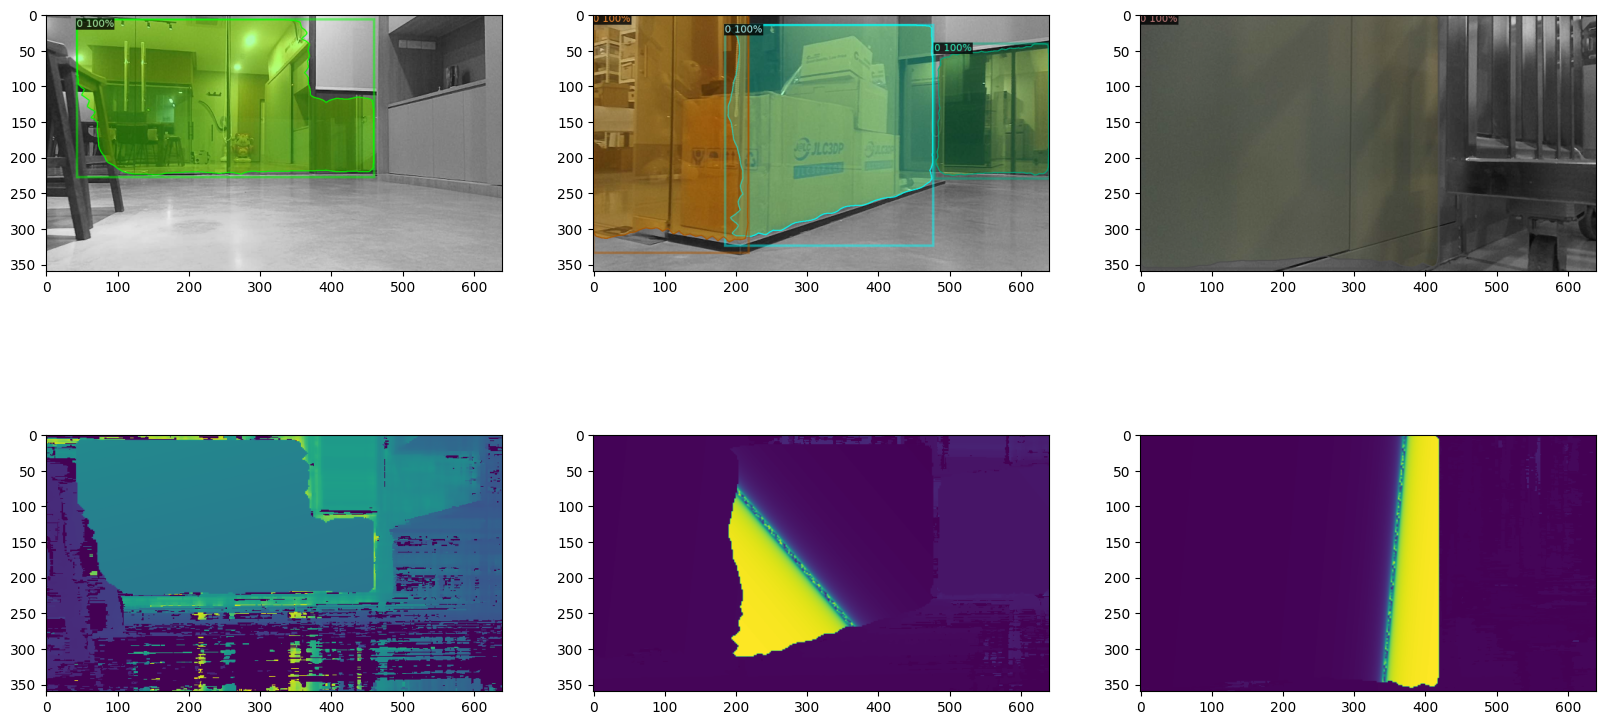

In [27]:
_, axs = plt.subplots(2, 3, figsize=(20, 10))
axs[0, 0].imshow(dump_batch[0]['output_img'][..., ::-1])
axs[0, 1].imshow(dump_batch[1]['output_img'][..., ::-1])
axs[0, 2].imshow(dump_batch[2]['output_img'][..., ::-1])

axs[1, 0].imshow(dump_batch[0]['refined_depth'], cmap="viridis")
axs[1, 1].imshow(dump_batch[1]['refined_depth'], cmap="viridis")
axs[1, 2].imshow(dump_batch[2]['refined_depth'], cmap="viridis")

plt.show()

In [49]:
instances.pred_masks

tensor([[[False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         ...,
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False]]])